In [1]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Sequence, Callable
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

In [2]:
# ============================================================
# Configuration:
#   -   Cut period to remove initialization bias
#   -   Remove failed operations from analysis
# ============================================================

# Cut period in seconds - operations in the first N seconds will be excluded
CUT_PERIOD_SECONDS = 10.0

def apply_cut_period(df: pd.DataFrame, cut_seconds: float = CUT_PERIOD_SECONDS) -> pd.DataFrame:
    """
    Filter out operations that started within the first cut_seconds of the run.
    This removes initialization bias from the analysis.
    """
    if len(df) == 0 or cut_seconds <= 0:
        return df
    
    t0 = df["ts_start"].min()
    cutoff_time = t0 + pd.Timedelta(seconds=cut_seconds)
    
    mask = df["ts_start"] >= cutoff_time
    return df[mask].copy()

def remove_failed_operations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove operations that failed (status != "success") from the analysis.
    This focuses the analysis on successful operations only.
    """
    if len(df) == 0:
        return df
    
    df = df[df["success"] == True].copy()

    return df


In [3]:
# ============================================================
# Import a dataframe from a CSV file and preprocess it for analysis.
# ============================================================

def load_summary(file_path: str) -> pd.DataFrame:
    # Load the data from the CSV file
    df = pd.read_csv(file_path)

    # Basic validation
    required = {"ts_start", "ts_end", "success", "latency_ms"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts_start and ts_end columns to datetime format
    df['ts_start'] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    df['ts_end'] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")

    return df

def load_events(file_path: str) -> pd.DataFrame:
    # Load the data from the JSONL file
    df = pd.read_json(file_path, lines=True)

    # Basic validation
    required = {"phase", "nodeId", "reqId"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts column to datetime format
    df['ts'] = pd.to_datetime(df["ts"], utc=True, errors="coerce")

    # Change the nodeId from "15" to "node_15"
    df['nodeId'] = df['nodeId'].apply(lambda x: f"node_{x}" if isinstance(x, int) else x)

    return df

In [4]:
# ============================================================
# Given summary and events return summary with reason of failure for failed operations.
# ============================================================

DEC_PREFIX = "DEC_"

def classify_from_phase(phase: str, op: str) -> Optional[str]:
    """
    Map DEC event phase to failure cause.
    Returns one of: TIMEOUT, UNAVAILABLE, SUCCESS, None
    """
    if not phase:
        return None
    p = str(phase).strip().upper()

    # We only care about DEC events
    if not p.startswith(DEC_PREFIX):
        return None

    # Examples: DEC_GET_TIMEOUT, DEC_UPDATE_FAIL, DEC_GET_SUCCESS ...
    if op == "GET":
        if p == "DEC_GET_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_GET_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_GET_SUCCESS":
            return "SUCCESS"
    elif op == "UPDATE":
        if p == "DEC_UPDATE_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_UPDATE_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_UPDATE_SUCCESS":
            return "SUCCESS"

    # If you ever add other DEC_* phases, you can extend here
    return None

def enrich_summary_with_failure_reasons(summary: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich summary with failure reasons from events.
    Events use: nodeId (converted to "node_XX"), reqId
    Summary uses: node_id, req_id, op
    """
    # Filter events to only include DEC_ events
    dec_events = events[events["phase"].str.startswith(DEC_PREFIX, na=False)].copy()
    
    # Create a mapping of (nodeId, reqId) -> op from summary
    # Summary columns: node_id, req_id, op
    op_map = summary.set_index(["node_id", "req_id"])["op"].to_dict()
    
    # Classify each event using the phase and corresponding op
    def get_reason(row):
        # Events already have nodeId converted to "node_XX" format by load_events
        op = op_map.get((row["nodeId"], row["reqId"]))
        if op:
            return classify_from_phase(row["phase"], op)
        return None
    
    dec_events["reason"] = dec_events.apply(get_reason, axis=1)
    
    # Create a mapping of (nodeId, reqId) to reason (only keep non-None reasons)
    reason_map = dec_events[dec_events["reason"].notna()].set_index(["nodeId", "reqId"])["reason"].to_dict()
    
    # Create a new column in the summary for the failure reason
    # If not found in DEC_ events (i.e., INT_ events), assign "REJECTED"
    summary["failure_reason"] = summary.apply(
        lambda row: reason_map.get((row["node_id"], row["req_id"]), "REJECTED") if not row["success"] else None,
        axis=1
    )
    
    return summary


In [5]:

# ============================================================
# 2) Run-level (per-run) estimators
#    Each returns ONE number per run
# ============================================================

def run_mean_latency_ms(df: pd.DataFrame) -> float:
    """Mean latency in ms for this run."""
    return float(df["latency_ms"].astype(float).mean())


def run_quantile_latency_ms(df: pd.DataFrame, q: float) -> float:
    """Latency quantile (e.g. q=0.5 for median, 0.9, 0.99) for this run."""
    return float(df["latency_ms"].astype(float).quantile(q))


def run_throughput_ops_per_s(df: pd.DataFrame) -> float:
    """
    Throughput = completed ops / elapsed seconds in the run window.
    Uses ts_start min and ts_end max.
    """

    t0 = df["ts_start"].min()
    t1 = df["ts_end"].max()
    elapsed_s = (t1 - t0).total_seconds()

    if elapsed_s <= 0:
        return float("nan")

    return float(len(df) / elapsed_s)

def run_failure_rate(df: pd.DataFrame) -> float:
    """Failure rate = (# failed ops) / (# total ops) in this run."""
    total = len(df)
    if total == 0:
        return float("nan")
    fails = int((df["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_update(df: pd.DataFrame) -> float:
    """Failure rate for update operations only."""
    updates = df[df["op"] == "UPDATE"]
    total = len(updates)
    if total == 0:
        return float("nan")
    fails = int((updates["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_read(df: pd.DataFrame) -> float:
    """Failure rate for read operations only."""
    reads = df[df["op"] == "GET"]
    total = len(reads)
    if total == 0:
        return float("nan")
    fails = int((reads["success"] == False).sum())
    return float(fails / total)

def run_request_per_node(df: pd.DataFrame) -> np.array:
    """Number of requests per node"""
    return df.groupby("node_id")["op"].count().values

def run_request_per_key(df: pd.DataFrame) -> np.array:
    """Number of requests per key"""
    return df.groupby("key")["op"].count().values

def run_failure_rate_per_reason(df: pd.DataFrame) -> Dict[str, float]:
    """
    Failure rate broken down by failure reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    Returns the percentage of total operations that failed with each reason.
    """
    total_ops = len(df)
    if total_ops == 0:
        return {}
    
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    
    # Convert to rates (percentage of total operations)
    rates = {}
    for reason, count in failure_counts.items():
        rates[reason] = float(count / total_ops)
    
    rates["SUCCESS"] = float((df["success"] == True).sum() / total_ops)
    
    return rates

def run_failure_count_per_reason(df: pd.DataFrame) -> Dict[str, int]:
    """
    Count of failures by reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    """
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    failure_counts["SUCCESS"] = (df["success"] == True).sum()
    return failure_counts.to_dict()


In [6]:
# ============================================================
# 3) Confidence intervals across runs
# ============================================================

def t_critical_95(df: int) -> float:
    """
    95% two-sided t critical values for small df (1..30).
    Enough for b=10/20/30.
    If df is larger, we approximate with 1.96.
    """
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042
    }
    return table.get(df, 1.96)

def ci_mean_t(values: Sequence[float], confidence: float = 0.95) -> Tuple[float, float, float]:
    """
    Student-t CI for the mean of run-level values.
    Returns (mean, lo, hi).
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n < 2:
        return (float("nan"), float("nan"), float("nan"))

    mean = sum(xs) / n
    # sample standard deviation (unbiased)
    var = sum((x - mean) ** 2 for x in xs) / (n - 1)
    s = math.sqrt(var)
    se = s / math.sqrt(n)

    # We keep it simple: assume 95% by default
    if abs(confidence - 0.95) > 1e-9:
        raise ValueError("This simple helper supports only 95% CI. Extend if needed.")
    tcrit = t_critical_95(n - 1)

    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return (mean, lo, hi)


def bootstrap_ci_stat(
    values: Sequence[float],
    stat_fn: Callable[[List[float]], float],
    confidence: float = 0.95,
    n_boot: int = 5000,
    seed: int = 0,
) -> Tuple[float, float, float]:
    """
    Bootstrap percentile CI for a statistic over run-level values.
    Returns (point_estimate, lo, hi).

    IMPORTANT: values here should be run-level statistics (e.g., 10 medians),
    not per-operation samples.
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n == 0:
        return (float("nan"), float("nan"), float("nan"))

    rng = random.Random(seed)

    point = stat_fn(xs)

    boot_stats = []
    for _ in range(n_boot):
        sample = [xs[rng.randrange(n)] for _ in range(n)]
        boot_stats.append(stat_fn(sample))

    boot_stats.sort()

    alpha = 1.0 - confidence
    lo_idx = int(math.floor((alpha / 2) * n_boot))
    hi_idx = int(math.ceil((1 - alpha / 2) * n_boot)) - 1
    lo = boot_stats[max(0, min(lo_idx, n_boot - 1))]
    hi = boot_stats[max(0, min(hi_idx, n_boot - 1))]

    return (point, lo, hi)

def median_stat(xs: List[float]) -> float:
    """Median of a list (no numpy)."""
    ys = sorted(xs)
    n = len(ys)
    mid = n // 2
    if n % 2 == 1:
        return float(ys[mid])
    return float((ys[mid - 1] + ys[mid]) / 2)


def quantile_stat(q: float) -> Callable[[List[float]], float]:
    """
    Return a stat function that computes a quantile of a list via
    simple linear interpolation between sorted points.
    """
    def _q(xs: List[float]) -> float:
        ys = sorted(xs)
        n = len(ys)
        if n == 1:
            return float(ys[0])
        # position in [0, n-1]
        pos = q * (n - 1)
        lo = int(math.floor(pos))
        hi = int(math.ceil(pos))
        if lo == hi:
            return float(ys[lo])
        w = pos - lo
        return float(ys[lo] * (1 - w) + ys[hi] * w)
    return _q

In [7]:
def plot_cumulative_averages(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput over time for all runs in a folder.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    ax_lat, ax_thr = axes
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        # Sort by end time
        df = df.sort_values('ts_end').reset_index(drop=True)
        
        # Cumulative average latency
        cumsum_latency = df['latency_ms'].cumsum()
        cum_avg_latency = cumsum_latency / (np.arange(len(df)) + 1)
        
        # Cumulative average throughput (ops/s from start to each point)
        t0 = df['ts_start'].min()
        elapsed_seconds = (df['ts_end'] - t0).dt.total_seconds()
        cum_avg_throughput = (np.arange(len(df)) + 1) / elapsed_seconds
        
        # Plot
        label = folder.name
        ax_lat.plot(elapsed_seconds, cum_avg_latency, label=label, alpha=0.7)
        ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=label, alpha=0.7)
    
    # Configure latency plot
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency over Time - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Configure throughput plot
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput over Time - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

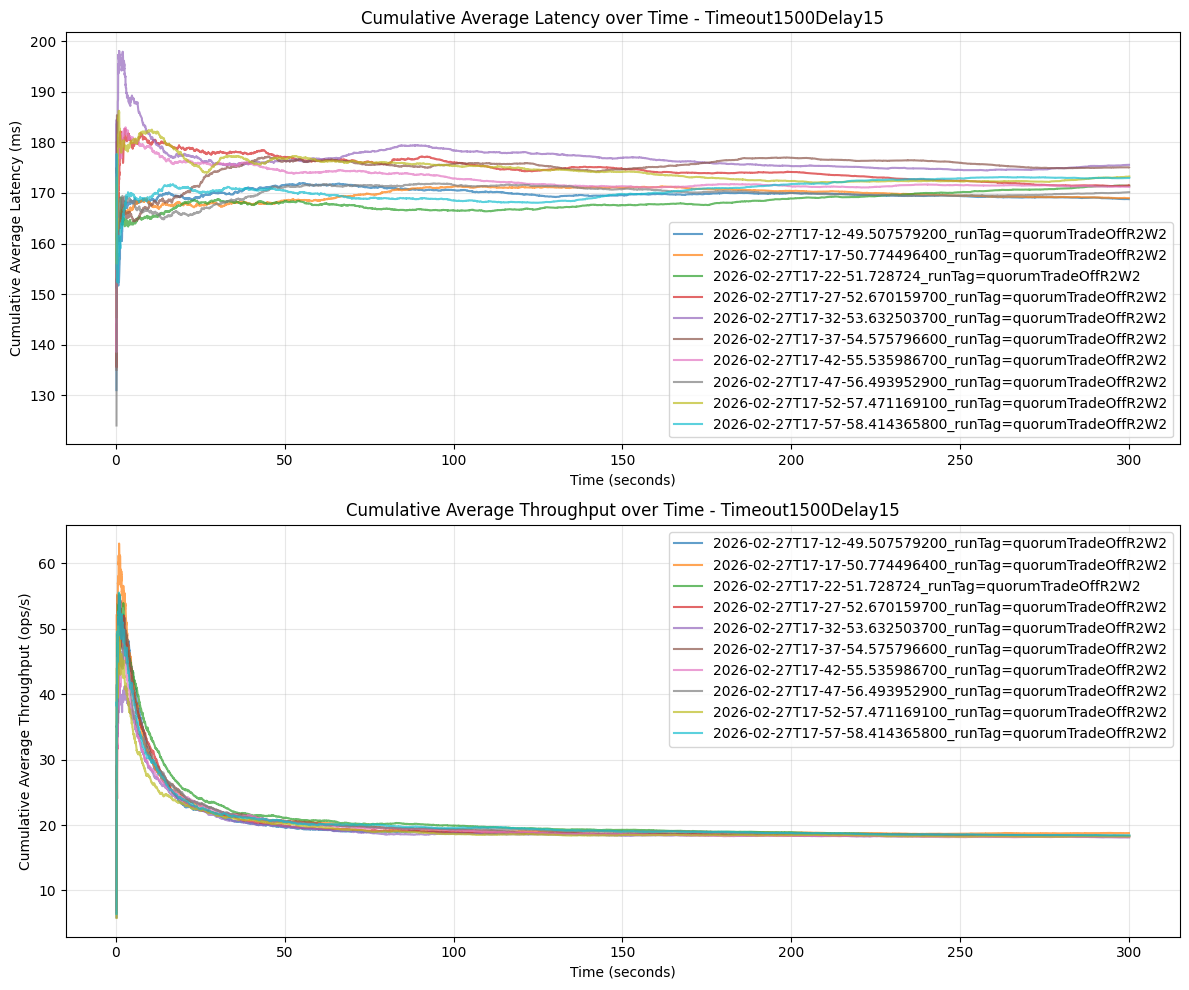

In [8]:
DATA_DIR = Path("Timeout1500Delay15")
SUMMARY_NAME = "summary.csv"

plot_cumulative_averages(DATA_DIR, apply_cut=False)

In [9]:
def plot_cumulative_averages_across_runs(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput across all runs in a configuration.
    This aggregates all operations from all runs and shows the cumulative average.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    # Collect all operations from all runs
    all_operations = []
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        all_operations.append(df)
    
    if len(all_operations) == 0:
        print(f"No data found in {data_dir}")
        return
    
    # Combine all runs
    combined_df = pd.concat(all_operations, ignore_index=True)
    
    # Sort by end time
    combined_df = combined_df.sort_values('ts_end').reset_index(drop=True)
    
    # Cumulative average latency
    cumsum_latency = combined_df['latency_ms'].cumsum()
    cum_avg_latency = cumsum_latency / (np.arange(len(combined_df)) + 1)
    
    # Cumulative average throughput (ops/s from start to each point)
    t0 = combined_df['ts_start'].min()
    elapsed_seconds = (combined_df['ts_end'] - t0).dt.total_seconds()
    cum_avg_throughput = (np.arange(len(combined_df)) + 1) / elapsed_seconds
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=(6, 5))
    ax_lat, ax_thr = axes
    
    # Plot latency
    ax_lat.plot(elapsed_seconds, cum_avg_latency, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency Across All Runs - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Plot throughput
    ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput Across All Runs - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nConfiguration: {data_dir.name}")
    print(f"  Total runs: {len(all_operations)}")
    print(f"  Total successful operations: {len(combined_df)}")
    print(f"  Final cumulative average latency: {cum_avg_latency.iloc[-1]:.2f} ms")
    print(f"  Final cumulative average throughput: {cum_avg_throughput.iloc[-1]:.2f} ops/s")

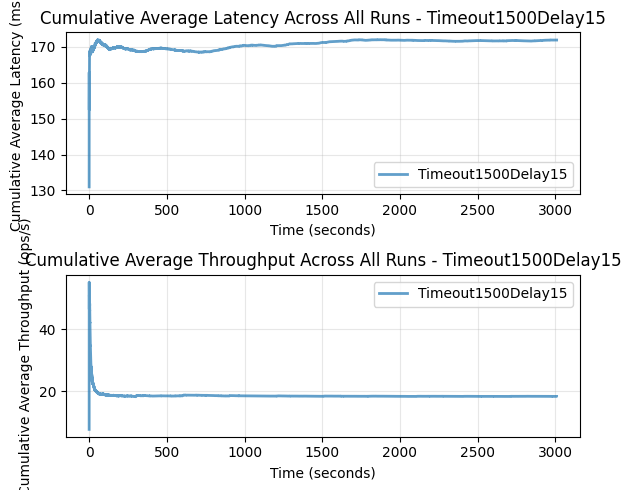


Configuration: Timeout1500Delay15
  Total runs: 10
  Total successful operations: 55050
  Final cumulative average latency: 171.88 ms
  Final cumulative average throughput: nan ops/s


In [10]:
plot_cumulative_averages_across_runs(Path("Timeout1500Delay15"), apply_cut=False)

Processing Timeout1500Delay15...


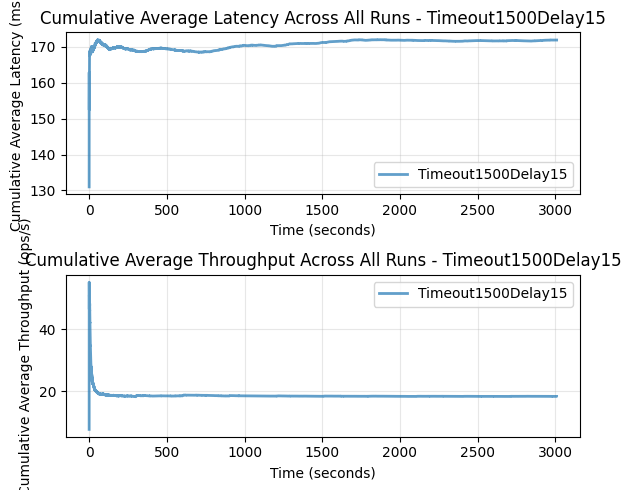


Configuration: Timeout1500Delay15
  Total runs: 10
  Total successful operations: 55050
  Final cumulative average latency: 171.88 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout1500Delay150...


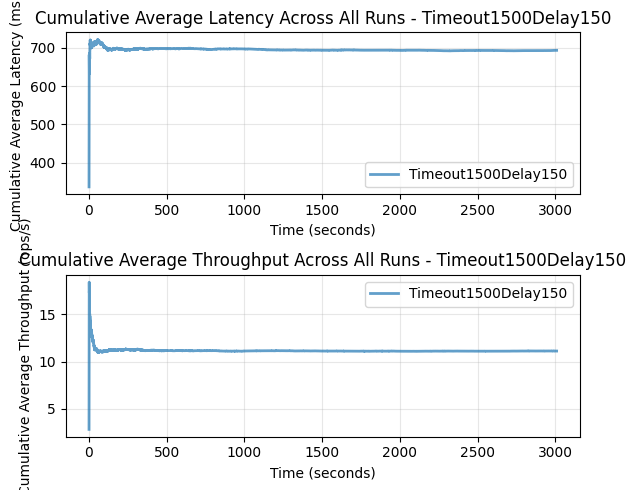


Configuration: Timeout1500Delay150
  Total runs: 10
  Total successful operations: 33515
  Final cumulative average latency: 693.01 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout1500Delay300...


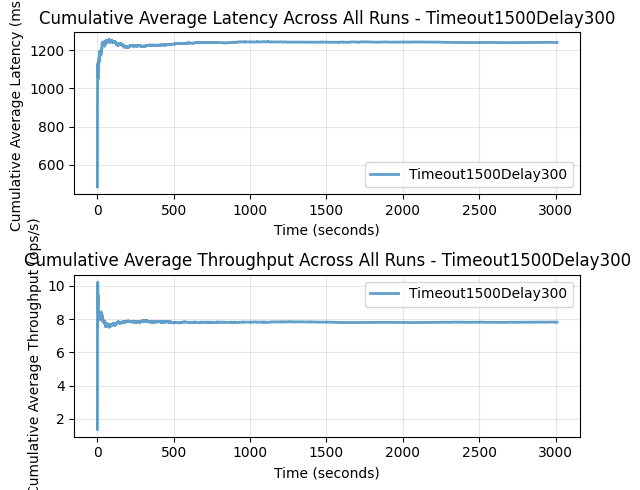


Configuration: Timeout1500Delay300
  Total runs: 10
  Total successful operations: 23539
  Final cumulative average latency: 1240.58 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout1500Delay50...


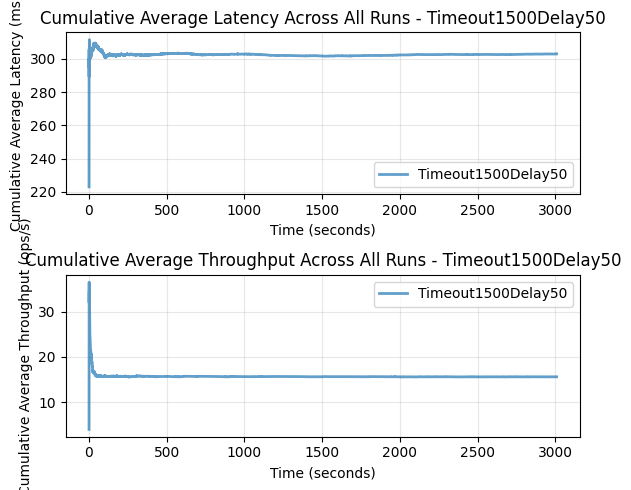


Configuration: Timeout1500Delay50
  Total runs: 10
  Total successful operations: 46914
  Final cumulative average latency: 302.91 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout3000Delay15...


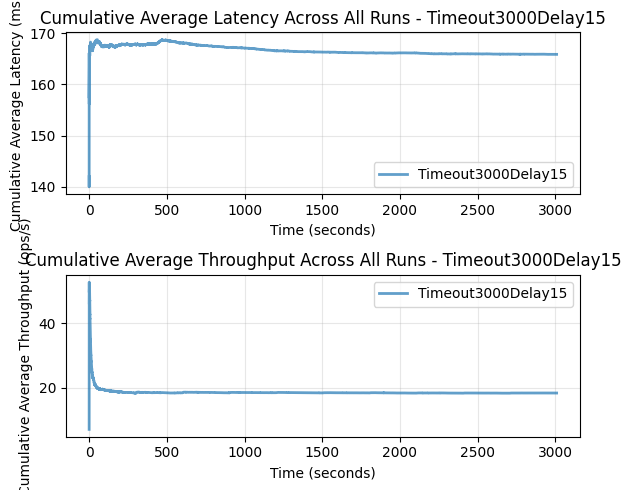


Configuration: Timeout3000Delay15
  Total runs: 10
  Total successful operations: 55163
  Final cumulative average latency: 165.87 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout3000Delay150...


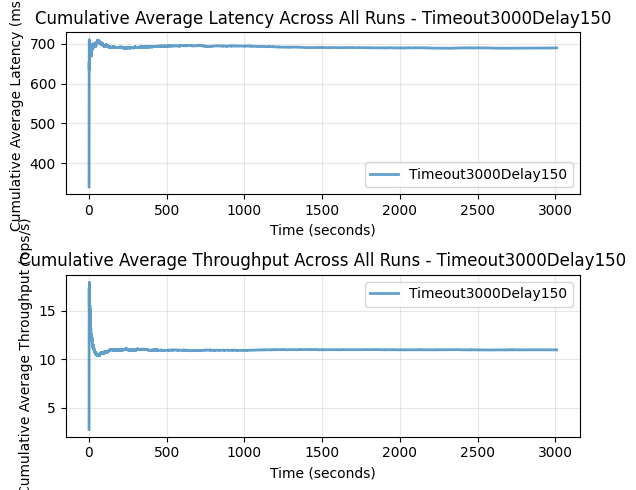


Configuration: Timeout3000Delay150
  Total runs: 10
  Total successful operations: 33025
  Final cumulative average latency: 689.84 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout3000Delay300...


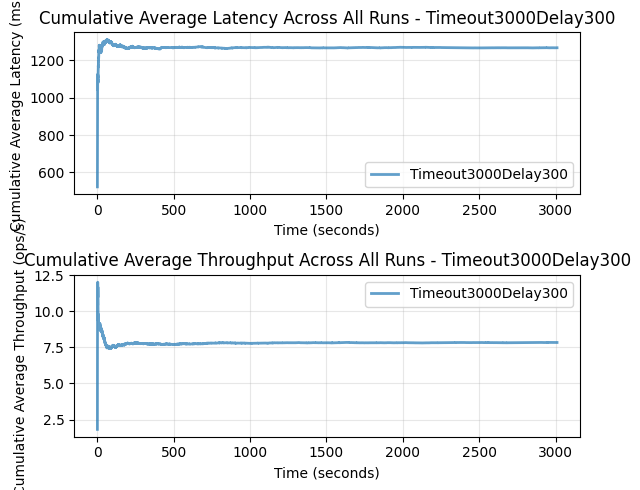


Configuration: Timeout3000Delay300
  Total runs: 10
  Total successful operations: 23614
  Final cumulative average latency: 1266.73 ms
  Final cumulative average throughput: nan ops/s
Processing Timeout3000Delay50...


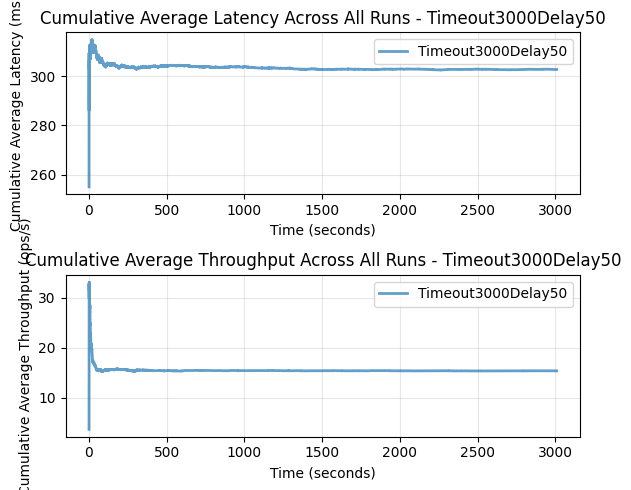


Configuration: Timeout3000Delay50
  Total runs: 10
  Total successful operations: 46296
  Final cumulative average latency: 302.79 ms
  Final cumulative average throughput: nan ops/s


In [11]:
BASE_DIR = Path("./")

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        plot_cumulative_averages_across_runs(Path(folder), apply_cut=False)

In [12]:
# You can adjust CUT_PERIOD_SECONDS at the top to change the cut period
# Current setting: first 10 seconds of each run are excluded from analysis
DATA_DIR = Path("Timeout1500Delay15")
SUMMARY_NAME = "summary.csv"

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        df = load_summary(folder / SUMMARY_NAME)
        df = apply_cut_period(df)
        filan_df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))
        print(f"Run: {folder.name}")
        print(f"  Failure rate by reason: {run_failure_rate_per_reason(filan_df)}")
        print(f"  Failure count by reason: {run_failure_count_per_reason(filan_df)}")

Run: 2026-02-27T17-12-49.507579200_runTag=quorumTradeOffR2W2
  Failure rate by reason: {'UNAVAILABLE': 0.027475567029319563, 'REJECTED': 0.02065277521666974, 'TIMEOUT': 0.0009219988936013276, 'SUCCESS': 0.9509496588604094}
  Failure count by reason: {'UNAVAILABLE': 149, 'REJECTED': 112, 'TIMEOUT': 5, 'SUCCESS': 5157}
Run: 2026-02-27T17-17-50.774496400_runTag=quorumTradeOffR2W2
  Failure rate by reason: {'UNAVAILABLE': 0.024337866857551897, 'REJECTED': 0.021474588403722263, 'TIMEOUT': 0.0008947745168217609, 'SUCCESS': 0.9532927702219041}
  Failure count by reason: {'UNAVAILABLE': 136, 'REJECTED': 120, 'TIMEOUT': 5, 'SUCCESS': 5327}
Run: 2026-02-27T17-22-51.728724_runTag=quorumTradeOffR2W2
  Failure rate by reason: {'UNAVAILABLE': 0.028274352426121852, 'REJECTED': 0.028091937249179133, 'TIMEOUT': 0.0007296607077708865, 'SUCCESS': 0.9429040496169281}
  Failure count by reason: {'UNAVAILABLE': 155, 'REJECTED': 154, 'TIMEOUT': 4, 'SUCCESS': 5169}
Run: 2026-02-27T17-27-52.670159700_runTag=qu

In [23]:
# ============================================================
# Compute statistics across runs and confidence intervals
# ============================================================

def compute_stat_across_runs(
    data_dir: Path,
) -> Dict:
    """
    Compute statistics across runs and confidence intervals.
    Returns a dictionary of statistic name -> (point_estimate, ci_lo, ci_hi).
    """
    p50_r = []
    p50_w = []
    p95_r = []
    p95_w = []
    p99_r = []
    p99_w = []

    throughput = []
    throughput_r = []
    throughput_w = []

    success_rate = []
    timeout_rate = []
    busy_rate = []
    p99 = []

    for folder in data_dir.iterdir():
        if folder.is_dir():
            df = load_summary(folder / SUMMARY_NAME)
            df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))

            df = apply_cut_period(df)

            df_success = remove_failed_operations(df)

            # Now I compute run-level stats
            df_r = df_success[df_success["op"] == "GET"]
            df_w = df_success[df_success["op"] == "UPDATE"]

            p50_r.append(run_quantile_latency_ms(df_r, 0.5))
            p50_w.append(run_quantile_latency_ms(df_w, 0.5))
            p95_r.append(run_quantile_latency_ms(df_r, 0.95))
            p95_w.append(run_quantile_latency_ms(df_w, 0.95))
            p99_r.append(run_quantile_latency_ms(df_r, 0.99))
            p99_w.append(run_quantile_latency_ms(df_w, 0.99))
            p99.append(run_quantile_latency_ms(df_success, 0.99))

            throughput.append(run_throughput_ops_per_s(df_success))
            throughput_r.append(run_throughput_ops_per_s(df_r))
            throughput_w.append(run_throughput_ops_per_s(df_w))

            rates = run_failure_rate_per_reason(df)
            success_rate.append(rates.get("SUCCESS", 0))
            timeout_rate.append(rates.get("TIMEOUT", 0))
            busy_rate.append(rates.get("UNAVAILABLE", 0) + rates.get("REJECTED", 0))
    
    # Compute mean and CI for each metric
    summary_stats = {
        "p99": {
            "median": bootstrap_ci_stat(p99, median_stat)
        },
        # Read latency percentiles
        "p50_read_ms": {
            "median": bootstrap_ci_stat(p50_r, median_stat)
        },
        "p95_read_ms": {
            "median": bootstrap_ci_stat(p95_r, median_stat)
        },
        "p99_read_ms": {
            "median": bootstrap_ci_stat(p99_r, median_stat)
        },
        
        # Write latency percentiles
        "p50_write_ms": {
            "median": bootstrap_ci_stat(p50_w, median_stat)
        },
        "p95_write_ms": {
            "median": bootstrap_ci_stat(p95_w, median_stat)
        },
        "p99_write_ms": {
            "median": bootstrap_ci_stat(p99_w, median_stat)
        },
        
        # Throughput metrics
        "throughput_ops_per_s": {
            "mean": ci_mean_t(throughput),
        },
        "throughput_read_ops_per_s": {
            "mean": ci_mean_t(throughput_r),
        },
        "throughput_write_ops_per_s": {
            "mean": ci_mean_t(throughput_w),
        },
        
        # Success and failure rates
        "success_rate": {
            "mean": ci_mean_t(success_rate),
        },
        "timeout_rate": {
            "mean": ci_mean_t(timeout_rate),
        },
        "busy_rate": {
            "mean": ci_mean_t(busy_rate),
        }
    }

    return summary_stats

In [24]:
BASE_DIR = Path("./")

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        stats = compute_stat_across_runs(Path(folder))
        final_stats[folder.name] = stats

Processing Timeout1500Delay15...
Processing Timeout1500Delay150...
Processing Timeout1500Delay300...
Processing Timeout1500Delay50...
Processing Timeout3000Delay15...
Processing Timeout3000Delay150...
Processing Timeout3000Delay300...
Processing Timeout3000Delay50...


In [25]:
# Print summaries from final_stats
def format_stat_with_ci(point: float, lo: float, hi: float) -> str:
    """Format a statistic with its CI as 'point [lo, hi]'"""
    return f"{point:.2f} [{lo:.2f}, {hi:.2f}]"

print("=" * 100)
print("FINAL STATISTICS SUMMARY")
print("=" * 100)

for config_name, stats in final_stats.items():
    print(f"\n{'=' * 100}")
    print(f"Configuration: {config_name}")
    print('=' * 100)
    
    for metric_name, estimators in stats.items():
        print(f"\n{metric_name}:")
        
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            print(f"  Mean:   {format_stat_with_ci(mean_point, mean_lo, mean_hi)}")
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            print(f"  Median: {format_stat_with_ci(median_point, median_lo, median_hi)}")


FINAL STATISTICS SUMMARY

Configuration: Timeout1500Delay15

p99:
  Median: 262.50 [258.50, 265.00]

p50_read_ms:
  Median: 167.50 [166.00, 169.00]

p95_read_ms:
  Median: 225.50 [220.50, 228.00]

p99_read_ms:
  Median: 257.11 [251.88, 259.00]

p50_write_ms:
  Median: 172.00 [170.50, 175.50]

p95_write_ms:
  Median: 237.00 [234.00, 239.00]

p99_write_ms:
  Median: 271.00 [266.14, 273.00]

throughput_ops_per_s:
  Mean:   17.89 [17.75, 18.03]

throughput_read_ops_per_s:
  Mean:   12.50 [12.37, 12.63]

throughput_write_ops_per_s:
  Mean:   5.39 [5.32, 5.47]

success_rate:
  Mean:   0.95 [0.95, 0.95]

timeout_rate:
  Mean:   0.00 [0.00, 0.00]

busy_rate:
  Mean:   0.05 [0.05, 0.05]

Configuration: Timeout1500Delay150

p99:
  Median: 1510.85 [1479.43, 1526.98]

p50_read_ms:
  Median: 632.50 [625.00, 641.75]

p95_read_ms:
  Median: 1155.55 [1148.17, 1175.87]

p99_read_ms:
  Median: 1482.27 [1439.04, 1518.81]

p50_write_ms:
  Median: 686.75 [682.00, 695.50]

p95_write_ms:
  Median: 1255.05 [1

In [26]:
# Create a comparative DataFrame across all configurations
comparison_rows = []

for config_name, stats in final_stats.items():
    row = {"configuration": config_name}
    
    for metric_name, estimators in stats.items():
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            row[f"{metric_name}_mean"] = mean_point
            row[f"{metric_name}_mean_ci_lo"] = mean_lo
            row[f"{metric_name}_mean_ci_hi"] = mean_hi
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            row[f"{metric_name}_median"] = median_point
            row[f"{metric_name}_median_ci_lo"] = median_lo
            row[f"{metric_name}_median_ci_hi"] = median_hi
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 100)
print("COMPARATIVE STATISTICS TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False))

# You can save it to CSV:
# comparison_df.to_csv("quorum_comparison.csv", index=False)



COMPARATIVE STATISTICS TABLE
      configuration  p99_median  p99_median_ci_lo  p99_median_ci_hi  p50_read_ms_median  p50_read_ms_median_ci_lo  p50_read_ms_median_ci_hi  p95_read_ms_median  p95_read_ms_median_ci_lo  p95_read_ms_median_ci_hi  p99_read_ms_median  p99_read_ms_median_ci_lo  p99_read_ms_median_ci_hi  p50_write_ms_median  p50_write_ms_median_ci_lo  p50_write_ms_median_ci_hi  p95_write_ms_median  p95_write_ms_median_ci_lo  p95_write_ms_median_ci_hi  p99_write_ms_median  p99_write_ms_median_ci_lo  p99_write_ms_median_ci_hi  throughput_ops_per_s_mean  throughput_ops_per_s_mean_ci_lo  throughput_ops_per_s_mean_ci_hi  throughput_read_ops_per_s_mean  throughput_read_ops_per_s_mean_ci_lo  throughput_read_ops_per_s_mean_ci_hi  throughput_write_ops_per_s_mean  throughput_write_ops_per_s_mean_ci_lo  throughput_write_ops_per_s_mean_ci_hi  success_rate_mean  success_rate_mean_ci_lo  success_rate_mean_ci_hi  timeout_rate_mean  timeout_rate_mean_ci_lo  timeout_rate_mean_ci_hi  busy_rate_

In [27]:
i = 0
for key, value in final_stats.items():
    print(f"{key}:")
    if (i == 0):
        for metric, estimators in value.items():
            print(f"  {metric}:")
            for est_name, (point, lo, hi) in estimators.items():
                print(f"    {est_name}: {format_stat_with_ci(point, lo, hi)}")
    i += 1

Timeout1500Delay15:
  p99:
    median: 262.50 [258.50, 265.00]
  p50_read_ms:
    median: 167.50 [166.00, 169.00]
  p95_read_ms:
    median: 225.50 [220.50, 228.00]
  p99_read_ms:
    median: 257.11 [251.88, 259.00]
  p50_write_ms:
    median: 172.00 [170.50, 175.50]
  p95_write_ms:
    median: 237.00 [234.00, 239.00]
  p99_write_ms:
    median: 271.00 [266.14, 273.00]
  throughput_ops_per_s:
    mean: 17.89 [17.75, 18.03]
  throughput_read_ops_per_s:
    mean: 12.50 [12.37, 12.63]
  throughput_write_ops_per_s:
    mean: 5.39 [5.32, 5.47]
  success_rate:
    mean: 0.95 [0.95, 0.95]
  timeout_rate:
    mean: 0.00 [0.00, 0.00]
  busy_rate:
    mean: 0.05 [0.05, 0.05]
Timeout1500Delay150:
Timeout1500Delay300:
Timeout1500Delay50:
Timeout3000Delay15:
Timeout3000Delay150:
Timeout3000Delay300:
Timeout3000Delay50:


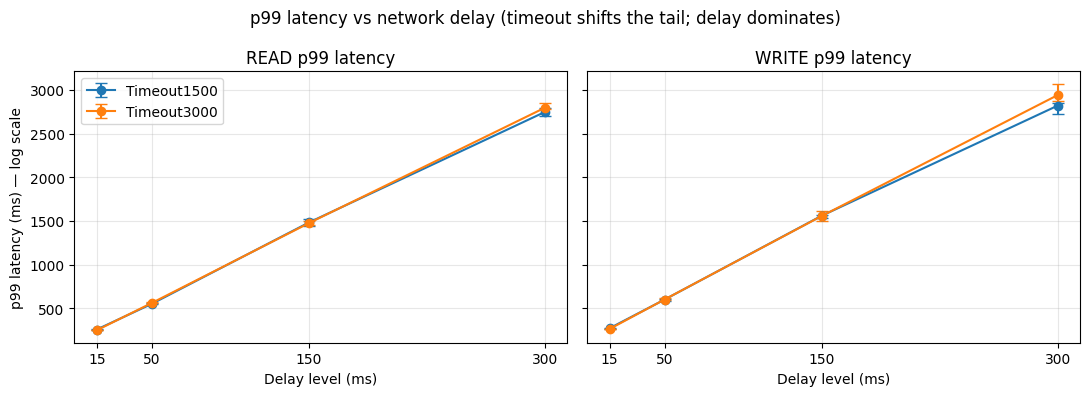

In [28]:
# P99_DELAY_DATA[timeout_label][delay_level] = {"read": (pt, lo, hi), "write": (pt, lo, hi)}
P99_DELAY_DATA = {
    "Timeout1500": {
        15:  {"read": final_stats["Timeout1500Delay15"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout1500Delay15"]["p99_write_ms"]["median"]
        },
        50:  {"read": final_stats["Timeout1500Delay50"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout1500Delay50"]["p99_write_ms"]["median"]
        },
        150: {"read": final_stats["Timeout1500Delay150"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout1500Delay150"]["p99_write_ms"]["median"]
        },
        300: {"read": final_stats["Timeout1500Delay300"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout1500Delay300"]["p99_write_ms"]["median"]
        },
    },
    "Timeout3000": {
        15:  {"read": final_stats["Timeout3000Delay15"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout3000Delay15"]["p99_write_ms"]["median"]
        },
        50:  {"read": final_stats["Timeout3000Delay50"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout3000Delay50"]["p99_write_ms"]["median"]
        },
        150: {"read": final_stats["Timeout3000Delay150"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout3000Delay150"]["p99_write_ms"]["median"]
        },
        300: {"read": final_stats["Timeout3000Delay300"]["p99_read_ms"]["median"],
         "write": final_stats["Timeout3000Delay300"]["p99_write_ms"]["median"]
        },
    },
}

# x-axis order
DELAY_LEVELS = [15, 50, 150, 300]
TIMEOUT_LINES = ["Timeout1500", "Timeout3000"]

def _asym_yerr(point, lo, hi):
    """Return yerr in the format matplotlib expects: [[lower...],[upper...]] distances."""
    return (point - lo, hi - point)

def plot_p99_vs_delay_two_panels(p99_delay_data: dict):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

    panels = [
        ("read",  "READ p99 latency"),
        ("write", "WRITE p99 latency"),
    ]

    for ax, (op_key, title) in zip(axes, panels):
        for tlabel in TIMEOUT_LINES:
            xs = np.array(DELAY_LEVELS, dtype=float)

            ys = []
            yerr_lo = []
            yerr_hi = []

            for d in DELAY_LEVELS:
                pt, lo, hi = p99_delay_data[tlabel][d][op_key]
                ys.append(pt)
                lo_e, hi_e = _asym_yerr(pt, lo, hi)
                yerr_lo.append(lo_e)
                yerr_hi.append(hi_e)

            ys = np.array(ys, dtype=float)
            yerr = np.vstack([yerr_lo, yerr_hi])

            ax.errorbar(
                xs, ys,
                yerr=yerr,
                marker="o",
                capsize=4,
                label=tlabel
            )

        ax.set_title(title)
        ax.set_xlabel("Delay level (ms)")
        ax.set_xscale("linear")
        # ax.set_yscale("log")            # key requirement
        ax.set_xticks(DELAY_LEVELS)
        ax.grid(True, which="both", alpha=0.3)

    axes[0].set_ylabel("p99 latency (ms) — log scale")
    axes[0].legend(loc="best")

    fig.suptitle("p99 latency vs network delay (timeout shifts the tail; delay dominates)")
    fig.tight_layout()
    plt.show()

# ---- call it ----
plot_p99_vs_delay_two_panels(P99_DELAY_DATA)

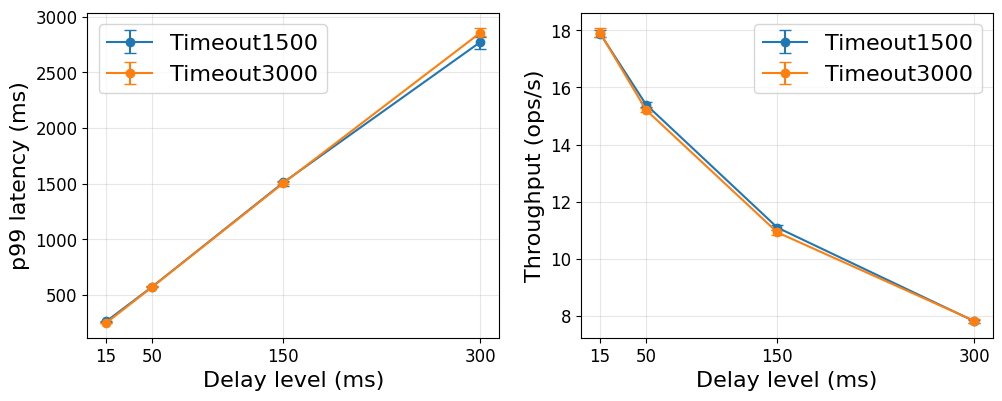

In [45]:
# P99_DELAY_DATA[timeout_label][delay_level] = {"read": (pt, lo, hi), "write": (pt, lo, hi)}
P99_DELAY_DATA = {
    "Timeout1500": {
        15:  {"p99": final_stats["Timeout1500Delay15"]["p99"]["median"],
         "throughput": final_stats["Timeout1500Delay15"]["throughput_ops_per_s"]["mean"]
        },
        50:  {"p99": final_stats["Timeout1500Delay50"]["p99"]["median"],
         "throughput": final_stats["Timeout1500Delay50"]["throughput_ops_per_s"]["mean"]
        },
        150: {"p99": final_stats["Timeout1500Delay150"]["p99"]["median"],
         "throughput": final_stats["Timeout1500Delay150"]["throughput_ops_per_s"]["mean"]
        },
        300: {"p99": final_stats["Timeout1500Delay300"]["p99"]["median"],
         "throughput": final_stats["Timeout1500Delay300"]["throughput_ops_per_s"]["mean"]
        },
    },
    "Timeout3000": {
        15:  {"p99": final_stats["Timeout3000Delay15"]["p99"]["median"],
         "throughput": final_stats["Timeout3000Delay15"]["throughput_ops_per_s"]["mean"]
        },
        50:  {"p99": final_stats["Timeout3000Delay50"]["p99"]["median"],
         "throughput": final_stats["Timeout3000Delay50"]["throughput_ops_per_s"]["mean"]
        },
        150: {"p99": final_stats["Timeout3000Delay150"]["p99"]["median"],
         "throughput": final_stats["Timeout3000Delay150"]["throughput_ops_per_s"]["mean"]
        },
        300: {"p99": final_stats["Timeout3000Delay300"]["p99"]["median"],
         "throughput": final_stats["Timeout3000Delay300"]["throughput_ops_per_s"]["mean"]
        },
    },
}

# x-axis order
DELAY_LEVELS = [15, 50, 150, 300]
TIMEOUT_LINES = ["Timeout1500", "Timeout3000"]

def _asym_yerr(point, lo, hi):
    """Return yerr in the format matplotlib expects: [[lower...],[upper...]] distances."""
    return (point - lo, hi - point)

def plot_p99_vs_delay_two_panels(p99_delay_data: dict):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    panels = [
        ("p99",  "p99 latency"),
        ("throughput", "Throughput (ops/s)"),
    ]

    for ax, (op_key, title) in zip(axes, panels):
        for tlabel in TIMEOUT_LINES:
            xs = np.array(DELAY_LEVELS, dtype=float)

            ys = []
            yerr_lo = []
            yerr_hi = []

            for d in DELAY_LEVELS:
                pt, lo, hi = p99_delay_data[tlabel][d][op_key]
                ys.append(pt)
                lo_e, hi_e = _asym_yerr(pt, lo, hi)
                yerr_lo.append(lo_e)
                yerr_hi.append(hi_e)

            ys = np.array(ys, dtype=float)
            yerr = np.vstack([yerr_lo, yerr_hi])

            ax.errorbar(
                xs, ys,
                yerr=yerr,
                marker="o",
                capsize=4,
                label=tlabel
            )

        #ax.set_title(title)
        ax.set_xlabel("Delay level (ms)")
        ax.set_xscale("linear")
        ax.set_xticks(DELAY_LEVELS)
        ax.grid(True, which="both", alpha=0.3)

    axes[0].set_ylabel("p99 latency (ms)")
    axes[1].set_ylabel("Throughput (ops/s)")
    axes[0].legend(loc="best", fontsize=16)
    axes[1].legend(loc="best", fontsize=16)

    #fig.suptitle("p99 latency and throughput vs network delay")
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.2)
    
    # Increase font sizes for axis labels
    for ax in axes:
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.xaxis.label.set_fontsize(16)
        ax.yaxis.label.set_fontsize(16)
    plt.savefig("failure_latency.png")
    plt.show()

# ---- call it ----
plot_p99_vs_delay_two_panels(P99_DELAY_DATA)


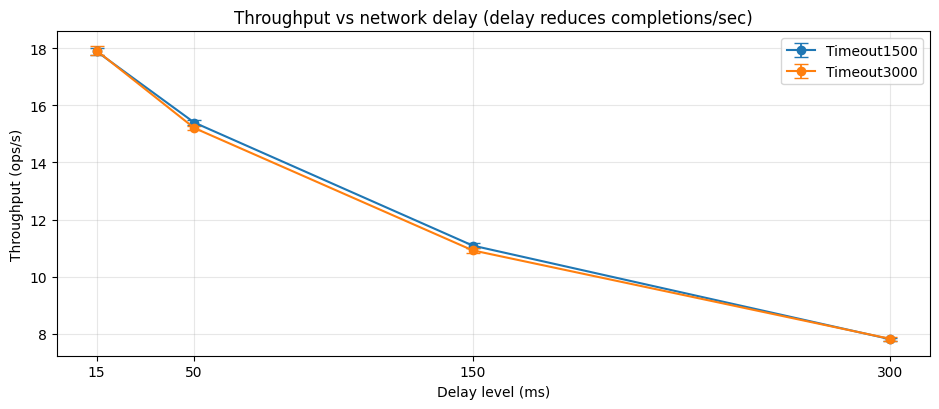

In [19]:
# ============================================================
# throughput_ops_per_s
# throughput_read_ops_per_s
# throughput_write_ops_per_s
# ============================================================

# THR_DELAY_DATA = {
#     "Timeout1500": {
#         15:  {"read": final_stats["Timeout1500Delay15"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout1500Delay15"]["throughput_write_ops_per_s"]["mean"]
#         },
#         50:  {"read": final_stats["Timeout1500Delay50"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout1500Delay50"]["throughput_write_ops_per_s"]["mean"]
#         },
#         150: {"read": final_stats["Timeout1500Delay150"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout1500Delay150"]["throughput_write_ops_per_s"]["mean"]
#         },
#         300: {"read": final_stats["Timeout1500Delay300"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout1500Delay300"]["throughput_write_ops_per_s"]["mean"]
#         },
#     },
#     "Timeout3000": {
#         15:  {"read": final_stats["Timeout3000Delay15"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout3000Delay15"]["throughput_write_ops_per_s"]["mean"]
#         },
#         50:  {"read": final_stats["Timeout3000Delay50"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout3000Delay50"]["throughput_write_ops_per_s"]["mean"]
#         },
#         150: {"read": final_stats["Timeout3000Delay150"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout3000Delay150"]["throughput_write_ops_per_s"]["mean"]
#         },
#         300: {"read": final_stats["Timeout3000Delay300"]["throughput_read_ops_per_s"]["mean"],
#          "write": final_stats["Timeout3000Delay300"]["throughput_write_ops_per_s"]["mean"]
#         },
#     },
# }
THR_DELAY_DATA = {
    "Timeout1500": {
        15:  final_stats["Timeout1500Delay15"]["throughput_ops_per_s"]["mean"],
        50:  final_stats["Timeout1500Delay50"]["throughput_ops_per_s"]["mean"],
        150: final_stats["Timeout1500Delay150"]["throughput_ops_per_s"]["mean"],
        300: final_stats["Timeout1500Delay300"]["throughput_ops_per_s"]["mean"],
    },
    "Timeout3000": {
        15:  final_stats["Timeout3000Delay15"]["throughput_ops_per_s"]["mean"],
        50:  final_stats["Timeout3000Delay50"]["throughput_ops_per_s"]["mean"],
        150: final_stats["Timeout3000Delay150"]["throughput_ops_per_s"]["mean"],
        300: final_stats["Timeout3000Delay300"]["throughput_ops_per_s"]["mean"],
    },
}


DELAY_LEVELS = [15, 50, 150, 300]
TIMEOUT_LINES = ["Timeout1500", "Timeout3000"]

# ============================================================
# 2) PLOT (same aesthetic as Plot 1)
# ============================================================
def _asym_yerr(point, lo, hi):
    return (point - lo, hi - point)

def plot_throughput_vs_delay(thr_delay_data: dict):
    fig, ax = plt.subplots(figsize=(9.5, 4.2))

    xs = np.array(DELAY_LEVELS, dtype=float)

    for tlabel in TIMEOUT_LINES:
        ys, yerr_lo, yerr_hi = [], [], []
        for d in DELAY_LEVELS:
            pt, lo, hi = thr_delay_data[tlabel][d]
            ys.append(pt)
            lo_e, hi_e = _asym_yerr(pt, lo, hi)
            yerr_lo.append(lo_e)
            yerr_hi.append(hi_e)

        ys = np.array(ys, dtype=float)
        yerr = np.vstack([yerr_lo, yerr_hi])

        ax.errorbar(
            xs, ys,
            yerr=yerr,
            marker="o",
            capsize=5,
            elinewidth=1.3,
            label=tlabel,
        )

    ax.set_xticks(DELAY_LEVELS)
    ax.set_xlabel("Delay level (ms)")
    ax.set_ylabel("Throughput (ops/s)")
    ax.set_title("Throughput vs network delay (delay reduces completions/sec)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_throughput_vs_delay(THR_DELAY_DATA)

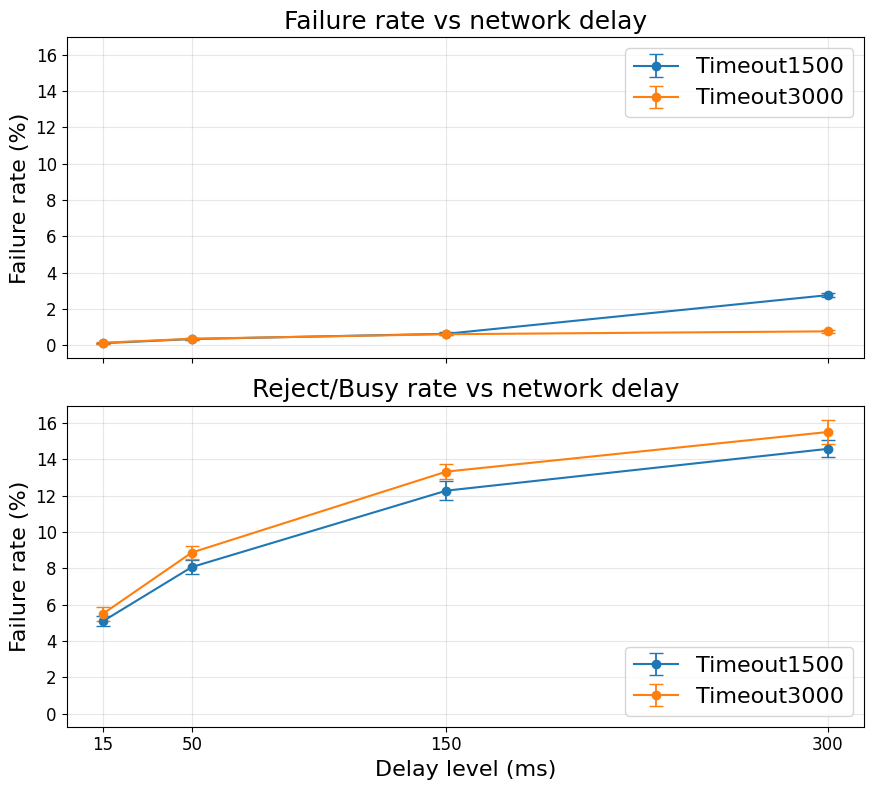

In [62]:
RATES_DELAY_DATA = {
    "Timeout1500": {
        15:  {"timeout": final_stats["Timeout1500Delay15"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay15"]["busy_rate"]["mean"]},
        50:  {"timeout": final_stats["Timeout1500Delay50"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay50"]["busy_rate"]["mean"]},
        150: {"timeout": final_stats["Timeout1500Delay150"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay150"]["busy_rate"]["mean"]},
        300: {"timeout": final_stats["Timeout1500Delay300"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay300"]["busy_rate"]["mean"]},
    },
    "Timeout3000": {
        15:  {"timeout": final_stats["Timeout3000Delay15"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay15"]["busy_rate"]["mean"]},
        50:  {"timeout": final_stats["Timeout3000Delay50"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay50"]["busy_rate"]["mean"]},
        150: {"timeout": final_stats["Timeout3000Delay150"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay150"]["busy_rate"]["mean"]},
        300: {"timeout": final_stats["Timeout3000Delay300"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay300"]["busy_rate"]["mean"]},
    },
}

DELAY_LEVELS = [15, 50, 150, 300]
TIMEOUT_LINES = ["Timeout1500", "Timeout3000"]

# ============================================================
# 2) PLOT (2 rows: timeout then busy)
# ============================================================
def _asym_yerr(point, lo, hi):
    return (point - lo, hi - point)

def plot_timeout_and_busy_vs_delay(rates_delay_data: dict):
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, sharey=True)
    ax_timeout, ax_busy = axes

    xs = np.array(DELAY_LEVELS, dtype=float)

    # ---- Top: timeout rate ----
    for tlabel in TIMEOUT_LINES:
        ys, yerr_lo, yerr_hi = [], [], []
        for d in DELAY_LEVELS:
            pt, lo, hi = rates_delay_data[tlabel][d]["timeout"]
            pt *= 100.0; lo *= 100.0; hi *= 100.0
            ys.append(pt)
            lo_e, hi_e = _asym_yerr(pt, lo, hi)
            yerr_lo.append(lo_e); yerr_hi.append(hi_e)

        yerr = np.vstack([yerr_lo, yerr_hi])
        ax_timeout.errorbar(
            xs, ys,
            yerr=yerr,
            marker="o",
            capsize=5,
            elinewidth=1.3,
            label=tlabel
        )

    ax_timeout.set_ylabel("Failure rate (%)")
    ax_timeout.set_title("Failure rate vs network delay", fontsize=18)
    ax_timeout.grid(True, alpha=0.3)
    ax_timeout.legend(loc="best", fontsize=16)

    # ---- Bottom: busy rate ----
    for tlabel in TIMEOUT_LINES:
        ys, yerr_lo, yerr_hi = [], [], []
        for d in DELAY_LEVELS:
            pt, lo, hi = rates_delay_data[tlabel][d]["busy"]
            pt *= 100.0; lo *= 100.0; hi *= 100.0
            ys.append(pt)
            lo_e, hi_e = _asym_yerr(pt, lo, hi)
            yerr_lo.append(lo_e); yerr_hi.append(hi_e)

        yerr = np.vstack([yerr_lo, yerr_hi])
        ax_busy.errorbar(
            xs, ys,
            yerr=yerr,
            marker="o",
            capsize=5,
            elinewidth=1.3,
            label=tlabel
        )

    ax_busy.set_ylabel("Failure rate (%)")
    ax_busy.set_title("Reject/Busy rate vs network delay", fontsize=18)
    ax_busy.set_xlabel("Delay level (ms)")
    ax_busy.set_xticks(DELAY_LEVELS)
    ax_busy.grid(True, alpha=0.3)
    ax_busy.legend(loc="lower right", fontsize=16)

    # Increase font sizes for axis labels
    for ax in axes:
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.xaxis.label.set_fontsize(16)
        ax.yaxis.label.set_fontsize(16)

    #fig.suptitle("Failure modes vs delay (timeouts and busy both increase)")
    fig.tight_layout()
    plt.savefig("failure.png")
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_timeout_and_busy_vs_delay(RATES_DELAY_DATA)

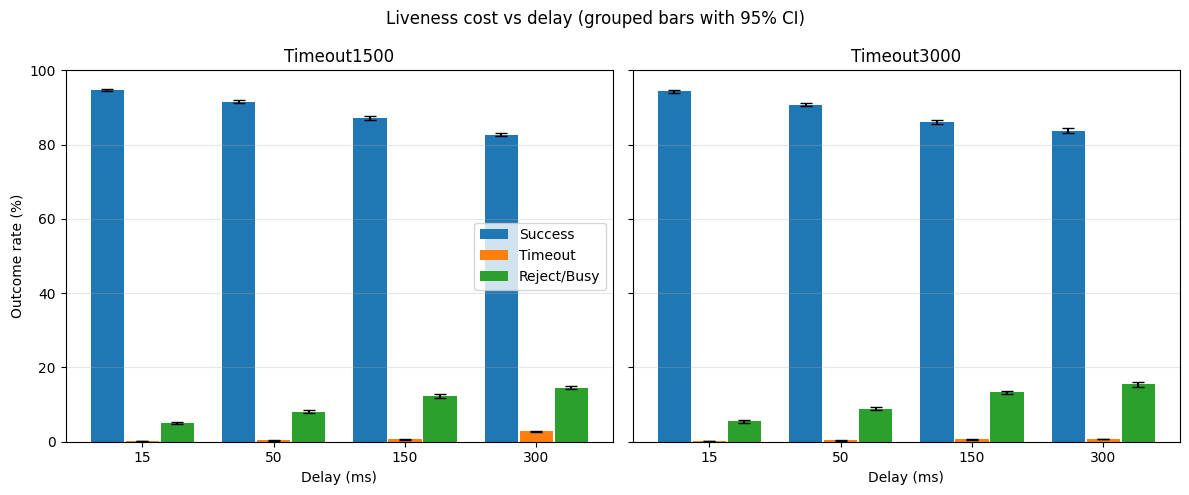

In [21]:
import numpy as np
import matplotlib.pyplot as plt

RATES_DELAY_DATA = {
    "Timeout1500": {
        15:  { "success": final_stats["Timeout1500Delay15"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout1500Delay15"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay15"]["busy_rate"]["mean"]},
        50:  { "success": final_stats["Timeout1500Delay50"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout1500Delay50"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay50"]["busy_rate"]["mean"]},
        150: { "success": final_stats["Timeout1500Delay150"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout1500Delay150"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay150"]["busy_rate"]["mean"]},
        300: { "success": final_stats["Timeout1500Delay300"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout1500Delay300"]["timeout_rate"]["mean"], "busy": final_stats["Timeout1500Delay300"]["busy_rate"]["mean"]},
    },
    "Timeout3000": {
        15:  { "success": final_stats["Timeout3000Delay15"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout3000Delay15"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay15"]["busy_rate"]["mean"]},
        50:  { "success": final_stats["Timeout3000Delay50"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout3000Delay50"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay50"]["busy_rate"]["mean"]},
        150: { "success": final_stats["Timeout3000Delay150"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout3000Delay150"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay150"]["busy_rate"]["mean"]},
        300: { "success": final_stats["Timeout3000Delay300"]["success_rate"]["mean"],
        "timeout": final_stats["Timeout3000Delay300"]["timeout_rate"]["mean"], "busy": final_stats["Timeout3000Delay300"]["busy_rate"]["mean"]},
    },
}

MIX_ORDER = [15, 50, 150, 300]
MEASURE_ORDER = ["success", "timeout", "busy"]

LABELS = {
    "success": "Success",
    "timeout": "Timeout",
    "busy": "Reject/Busy",
}

PLOT_AS_PERCENT = True

def _asymmetric_yerr(point, lo, hi):
    return (point - lo, hi - point)

def plot_liveness_grouped_bars_with_ci(bar_data_tuples, mix_order, measure_order, labels, plot_as_percent=True):
    configs = list(bar_data_tuples.keys())
    n_cfg = len(configs)
    fig, axes = plt.subplots(1, n_cfg, figsize=(12, 5), sharey=True)
    if n_cfg == 1:
        axes = [axes]

    x = np.arange(len(mix_order))
    n_measures = len(measure_order)
    group_width = 0.8
    bar_width = group_width / n_measures
    offsets = (np.arange(n_measures) - (n_measures - 1) / 2) * bar_width
    scale = 100.0 if plot_as_percent else 1.0
    y_label = "Outcome rate (%)" if plot_as_percent else "Outcome rate"

    for ax, cfg in zip(axes, configs):
        for j, meas in enumerate(measure_order):
            pts = []
            yerr_lo, yerr_hi = [], []

            for mix in mix_order:
                triple = bar_data_tuples[cfg].get(mix, {}).get(meas, None)
                pt, lo, hi = (triple if triple else (0.0, 0.0, 0.0))
                pts.append(pt * scale)
                dlo, dhi = _asymmetric_yerr(pt * scale, lo * scale, hi * scale)
                yerr_lo.append(dlo)
                yerr_hi.append(dhi)

            ax.bar(x + offsets[j], pts, width=bar_width * 0.95, 
                   yerr=np.vstack([yerr_lo, yerr_hi]), capsize=4, label=labels.get(meas, meas))

        ax.set_title(cfg)
        ax.set_xticks(x, mix_order)
        ax.set_xlabel("Delay (ms)")
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_ylim(0, 100 if plot_as_percent else 1)

    axes[0].set_ylabel(y_label)
    axes[0].legend(loc="best")
    fig.suptitle("Liveness cost vs delay (grouped bars with 95% CI)")
    fig.tight_layout()
    plt.show()

plot_liveness_grouped_bars_with_ci(RATES_DELAY_DATA, MIX_ORDER, MEASURE_ORDER, LABELS, plot_as_percent=PLOT_AS_PERCENT)
